#### Customer Churn Prediction & Retention Analysis

#### 1. Project Overview

This project aims to analyze customer churn behavior and develop machine learning models to predict customers who are likely to churn.

The analysis focuses on identifying key factors associated with customer churn and translating the model results into actionable customer retention strategies.

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

import joblib

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
# %% [markdown]
# # Customer Churn Prediction
# 
# This notebook analyzes customer churn patterns and builds machine learning
# models to predict customers who are likely to churn.

# %%
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:.2f}")

# Load dataset
df = pd.read_csv("../data/customer_churn_dataset-training-master.csv")

print("Dataset loaded successfully!")
print(f"Dataset shape: {df.shape}")

Dataset loaded successfully!
Dataset shape: (440833, 12)


In [4]:
# Display the first 5 rows
df.head()

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,2.00,30.00,Female,39.00,14.00,5.00,18.00,Standard,Annual,932.00,17.00,1.00
1,3.00,65.00,Female,49.00,1.00,10.00,8.00,Basic,Monthly,557.00,6.00,1.00
2,4.00,55.00,Female,14.00,4.00,6.00,18.00,Basic,Quarterly,185.00,3.00,1.00
3,5.00,58.00,Male,38.00,21.00,7.00,7.00,Standard,Monthly,396.00,29.00,1.00
4,6.00,23.00,Male,32.00,20.00,5.00,8.00,Basic,Monthly,617.00,20.00,1.00


In [6]:
# Check dataset information
print( "Dataset Information")
df.info()

Dataset Information
<class 'pandas.DataFrame'>
RangeIndex: 440833 entries, 0 to 440832
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   CustomerID         440832 non-null  float64
 1   Age                440832 non-null  float64
 2   Gender             440832 non-null  str    
 3   Tenure             440832 non-null  float64
 4   Usage Frequency    440832 non-null  float64
 5   Support Calls      440832 non-null  float64
 6   Payment Delay      440832 non-null  float64
 7   Subscription Type  440832 non-null  str    
 8   Contract Length    440832 non-null  str    
 9   Total Spend        440832 non-null  float64
 10  Last Interaction   440832 non-null  float64
 11  Churn              440832 non-null  float64
dtypes: float64(9), str(3)
memory usage: 40.4 MB


In [8]:
# Check missing values and duplicate rows

missing_values = df.isnull().sum()

print(" Missing Values ")
print(missing_values)

print("\nTotal rows containing missing values:",
      df.isnull().any(axis=1).sum())

print("Total duplicate rows:",
      df.duplicated().sum())

 Missing Values 
CustomerID           1
Age                  1
Gender               1
Tenure               1
Usage Frequency      1
Support Calls        1
Payment Delay        1
Subscription Type    1
Contract Length      1
Total Spend          1
Last Interaction     1
Churn                1
dtype: int64

Total rows containing missing values: 1
Total duplicate rows: 0


#### 2. Data Cleaning

The dataset was checked for missing values and duplicate records. Since one incomplete row was identified and there were no duplicate records, the incomplete row is removed before further analysis.

In [9]:
# Remove rows containing missing values

df_clean = df.dropna().copy()

print("Original dataset shape :", df.shape)
print("Cleaned dataset shape  :", df_clean.shape)
print("Rows removed           :", df.shape[0] - df_clean.shape[0])

Original dataset shape : (440833, 12)
Cleaned dataset shape  : (440832, 12)
Rows removed           : 1


#### 3. Churn Distribution

Before building the prediction model, the distribution of the target variable, Churn, is examined. This helps identify the proportion of customers who churned and those who remained active.

In [10]:
# Calculate churn distribution

churn_counts = df_clean["Churn"].value_counts().sort_index()
churn_percent = (
    df_clean["Churn"]
    .value_counts(normalize=True)
    .sort_index() * 100
)

print("Churn Distribution:\n")

for value in churn_counts.index:
    label = "No Churn" if value == 0 else "Churn"
    print(
        f"{label}: "
        f"{churn_counts[value]:,} customers "
        f"({churn_percent[value]:.2f}%)"
    )

Churn Distribution:

No Churn: 190,833 customers (43.29%)
Churn: 249,999 customers (56.71%)


C:\Users\Admin\AppData\Local\Temp\ipykernel_8232\325548348.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


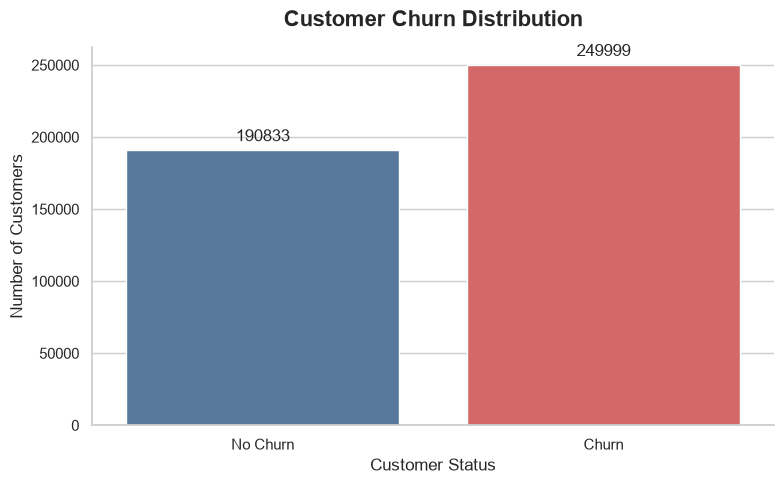

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style
sns.set_theme(style="whitegrid")

# Prepare labels
churn_plot = df_clean["Churn"].map({
    0: "No Churn",
    1: "Churn"
})

plt.figure(figsize=(8, 5))

ax = sns.countplot(
    x=churn_plot,
    order=["No Churn", "Churn"],
    palette=["#4C78A8", "#E45756"]
)

for container in ax.containers:
    ax.bar_label(container, fmt="%d", padding=4)

plt.title(
    "Customer Churn Distribution",
    fontsize=16,
    fontweight="bold",
    pad=15
)

plt.xlabel("Customer Status")
plt.ylabel("Number of Customers")

sns.despine()
plt.tight_layout()
plt.show()

#### 4. Descriptive Statistics

Descriptive statistics are used to understand the distribution and range of numerical customer characteristics, including age, tenure, usage frequency, support calls, payment delay, total spend, and last interaction.

In [12]:
# Display descriptive statistics for numerical variables

df_clean.describe().T

,count,mean,std,min,25%,50%,75%,max
CustomerID,440832.00,225398.67,129531.92,2.00,113621.75,226125.50,337739.25,449999.00
Age,440832.00,39.37,12.44,18.00,29.00,39.00,48.00,65.00
Tenure,440832.00,31.26,17.26,1.00,16.00,32.00,46.00,60.00
Usage Frequency,440832.00,15.81,8.59,1.00,9.00,16.00,23.00,30.00
Support Calls,440832.00,3.60,3.07,0.00,1.00,3.00,6.00,10.00
Payment Delay,440832.00,12.97,8.26,0.00,6.00,12.00,19.00,30.00
Total Spend,440832.00,631.62,240.80,100.00,480.00,661.00,830.00,1000.00
Last Interaction,440832.00,14.48,8.60,1.00,7.00,14.00,22.00,30.00
Churn,440832.00,0.57,0.50,0.00,0.00,1.00,1.00,1.00


#### 5. Categorical Feature Distribution

The distribution of categorical variables is examined to understand the composition of customers across gender, subscription type, and contract length.

In [13]:
# Analyze categorical features

categorical_columns = [
    "Gender",
    "Subscription Type",
    "Contract Length"
]

for column in categorical_columns:
    print(f"\n{column}")
    print("-" * 40)
    print(df_clean[column].value_counts())


Gender
----------------------------------------
Gender
Male      250252
Female    190580
Name: count, dtype: int64

Subscription Type
----------------------------------------
Subscription Type
Standard    149128
Premium     148678
Basic       143026
Name: count, dtype: int64

Contract Length
----------------------------------------
Contract Length
Annual       177198
Quarterly    176530
Monthly       87104
Name: count, dtype: int64


#### 6. Churn Rate by Gender

Churn rates are compared between male and female customers to identify whether customer gender is associated with different churn behavior.

In [14]:
# Calculate churn rate by gender

gender_churn = (
    df_clean.groupby("Gender")["Churn"]
    .agg(["count", "mean"])
    .reset_index()
)

gender_churn["Churn Rate (%)"] = gender_churn["mean"] * 100

gender_churn = gender_churn.drop(columns="mean")

gender_churn

,Gender,count,Churn Rate (%)
0,Female,190580,66.67
1,Male,250252,49.13


C:\Users\Admin\AppData\Local\Temp\ipykernel_8232\4265134030.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


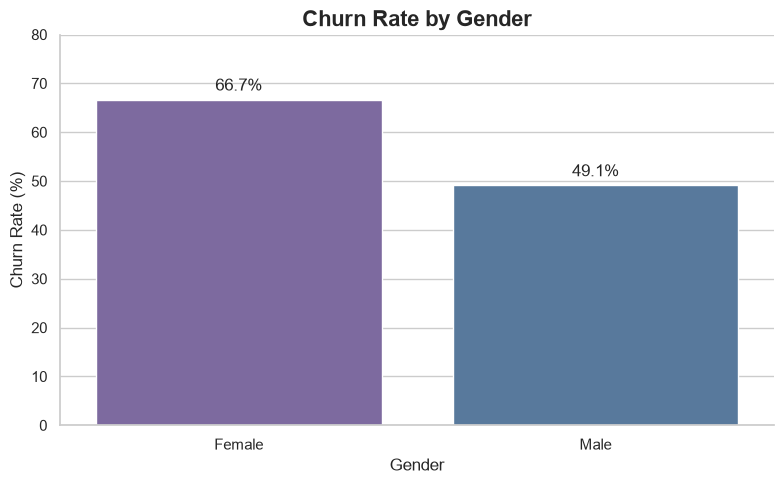

In [15]:
plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=gender_churn,
    x="Gender",
    y="Churn Rate (%)",
    palette=["#7B61A8", "#4C78A8"]
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        padding=4
    )

plt.title(
    "Churn Rate by Gender",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Gender")
plt.ylabel("Churn Rate (%)")
plt.ylim(0, 80)

sns.despine()
plt.tight_layout()
plt.show()

#### 7. Churn Rate by Subscription Type

Customer churn rates are compared across Basic, Standard, and Premium subscription plans to identify whether subscription level is associated with customer retention.

In [16]:
# Calculate churn rate by subscription type

subscription_churn = (
    df_clean.groupby("Subscription Type")["Churn"]
    .agg(["count", "mean"])
    .reset_index()
)

subscription_churn["Churn Rate (%)"] = (
    subscription_churn["mean"] * 100
)

subscription_churn = subscription_churn.drop(columns="mean")

subscription_churn

,Subscription Type,count,Churn Rate (%)
0,Basic,143026,58.18
1,Premium,148678,55.94
2,Standard,149128,56.07


C:\Users\Admin\AppData\Local\Temp\ipykernel_8232\610321820.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


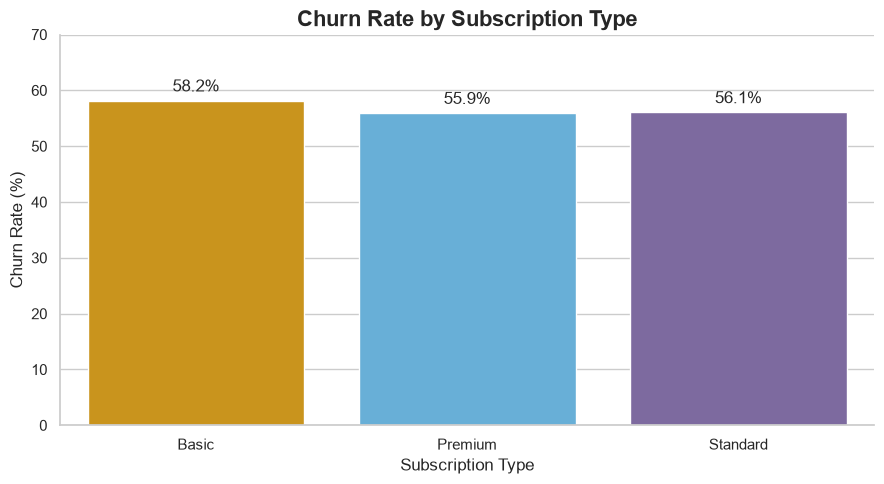

In [17]:
plt.figure(figsize=(9, 5))

ax = sns.barplot(
    data=subscription_churn,
    x="Subscription Type",
    y="Churn Rate (%)",
    palette=["#E69F00", "#56B4E9", "#7B61A8"]
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        padding=4
    )

plt.title(
    "Churn Rate by Subscription Type",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Subscription Type")
plt.ylabel("Churn Rate (%)")
plt.ylim(0, 70)

sns.despine()
plt.tight_layout()
plt.show()

#### 8. Churn Rate by Contract Length

Contract length is analyzed to determine whether customers with monthly, quarterly, or annual contracts have different churn rates.

In [18]:
# Calculate churn rate by contract length

contract_churn = (
    df_clean.groupby("Contract Length")["Churn"]
    .agg(["count", "sum", "mean"])
    .reset_index()
)

contract_churn["Churn Rate (%)"] = (
    contract_churn["mean"] * 100
)

contract_churn = contract_churn.sort_values(
    "Churn Rate (%)",
    ascending=False
)

contract_churn

,Contract Length,count,sum,mean,Churn Rate (%)
1,Monthly,87104,87104.00,1.00,100.00
0,Annual,177198,81646.00,0.46,46.08
2,Quarterly,176530,81249.00,0.46,46.03


C:\Users\Admin\AppData\Local\Temp\ipykernel_8232\1493455632.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


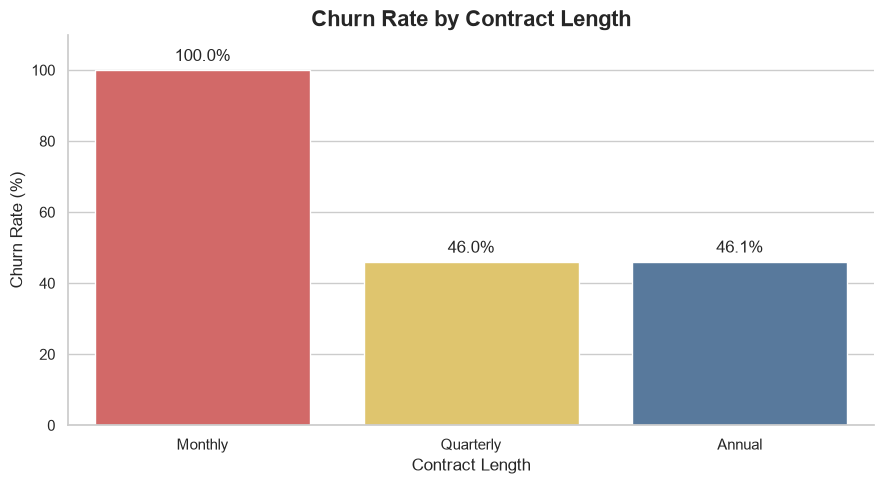

In [19]:
plt.figure(figsize=(9, 5))

ax = sns.barplot(
    data=contract_churn,
    x="Contract Length",
    y="Churn Rate (%)",
    order=["Monthly", "Quarterly", "Annual"],
    palette=["#E45756", "#F2CF5B", "#4C78A8"]
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        padding=4
    )

plt.title(
    "Churn Rate by Contract Length",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Contract Length")
plt.ylabel("Churn Rate (%)")
plt.ylim(0, 110)

sns.despine()
plt.tight_layout()
plt.show()

#### 9. Support Calls and Customer Churn

The relationship between the number of customer support calls and churn rate is analyzed to identify whether frequent support interactions indicate higher customer dissatisfaction or churn risk.

In [20]:
# Calculate churn rate by number of support calls

support_churn = (
    df_clean.groupby("Support Calls")["Churn"]
    .agg(["count", "mean"])
    .reset_index()
)

support_churn["Churn Rate (%)"] = (
    support_churn["mean"] * 100
)

support_churn

,Support Calls,count,mean,Churn Rate (%)
0,0.00,69875,0.30,30.28
1,1.00,69476,0.30,30.36
2,2.00,66571,0.32,31.55
3,3.00,52729,0.42,41.64
4,4.00,38750,0.58,58.50
5,5.00,24918,0.95,94.71
6,6.00,23554,1.00,100.00
7,7.00,23870,1.00,100.00
8,8.00,23559,1.00,100.00
9,9.00,23630,1.00,100.00


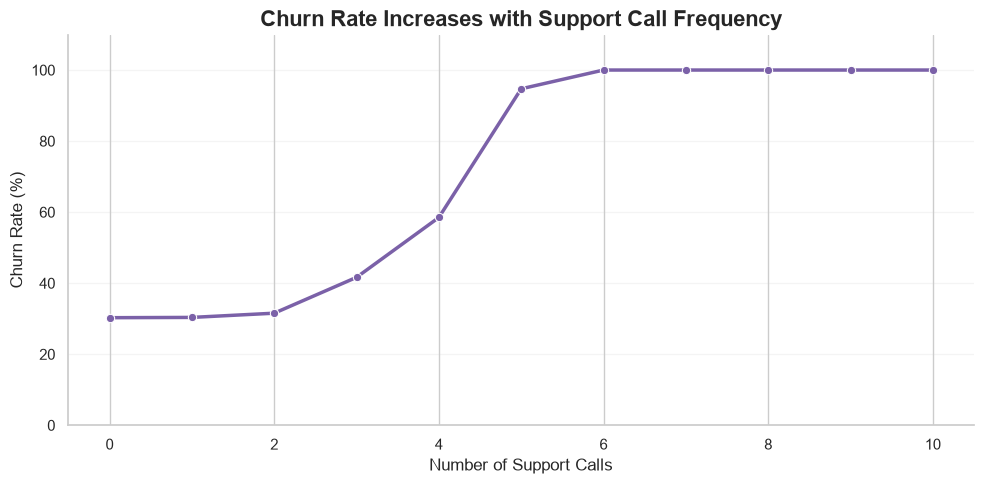

In [21]:
plt.figure(figsize=(10, 5))

sns.lineplot(
    data=support_churn,
    x="Support Calls",
    y="Churn Rate (%)",
    marker="o",
    linewidth=2.5,
    color="#7B61A8"
)

plt.title(
    "Churn Rate Increases with Support Call Frequency",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Number of Support Calls")
plt.ylabel("Churn Rate (%)")

plt.ylim(0, 110)
plt.grid(axis="y", alpha=0.2)

sns.despine()
plt.tight_layout()
plt.show()

#### 10. Payment Delay and Customer Churn

Payment delay is analyzed to determine whether delayed payments are associated with a higher likelihood of customer churn.

In [22]:
# Calculate churn rate by payment delay

payment_churn = (
    df_clean.groupby("Payment Delay")["Churn"]
    .agg(["count", "mean"])
    .reset_index()
)

payment_churn["Churn Rate (%)"] = (
    payment_churn["mean"] * 100
)

payment_churn

,Payment Delay,count,mean,Churn Rate (%)
0,0.00,16904,0.47,46.67
1,1.00,17021,0.46,45.78
2,2.00,16822,0.47,46.68
3,3.00,17025,0.47,46.58
4,4.00,16938,0.46,46.36
5,5.00,16744,0.47,46.62
6,6.00,16954,0.47,46.69
7,7.00,17027,0.46,46.33
8,8.00,16892,0.47,47.12
9,9.00,16869,0.47,46.66


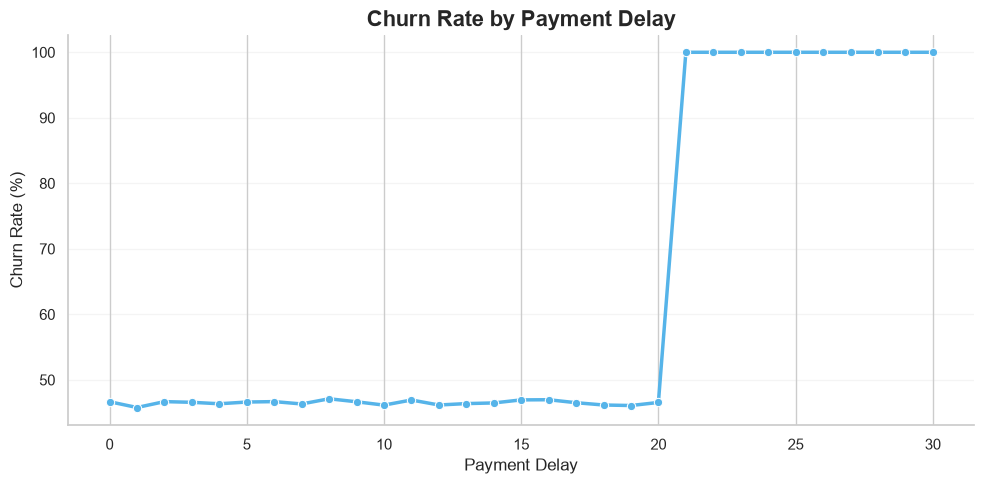

In [23]:
plt.figure(figsize=(10, 5))

sns.lineplot(
    data=payment_churn,
    x="Payment Delay",
    y="Churn Rate (%)",
    marker="o",
    linewidth=2.5,
    color="#56B4E9"
)

plt.title(
    "Churn Rate by Payment Delay",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Payment Delay")
plt.ylabel("Churn Rate (%)")

plt.grid(axis="y", alpha=0.2)

sns.despine()
plt.tight_layout()
plt.show()

#### 11. Usage Frequency and Customer Churn

Customer usage frequency is analyzed to determine whether lower engagement with the service is associated with a higher churn rate.

In [24]:
# Calculate churn rate by usage frequency

usage_churn = (
    df_clean.groupby("Usage Frequency")["Churn"]
    .agg(["count", "mean"])
    .reset_index()
)

usage_churn["Churn Rate (%)"] = (
    usage_churn["mean"] * 100
)

usage_churn

,Usage Frequency,count,mean,Churn Rate (%)
0,1.00,13797,0.62,61.72
1,2.00,13633,0.62,62.18
2,3.00,13843,0.61,60.77
3,4.00,13549,0.61,61.45
4,5.00,13716,0.61,61.40
5,6.00,13746,0.62,61.96
6,7.00,13555,0.60,59.84
7,8.00,13725,0.62,61.76
8,9.00,13770,0.61,61.23
9,10.00,15090,0.55,54.68


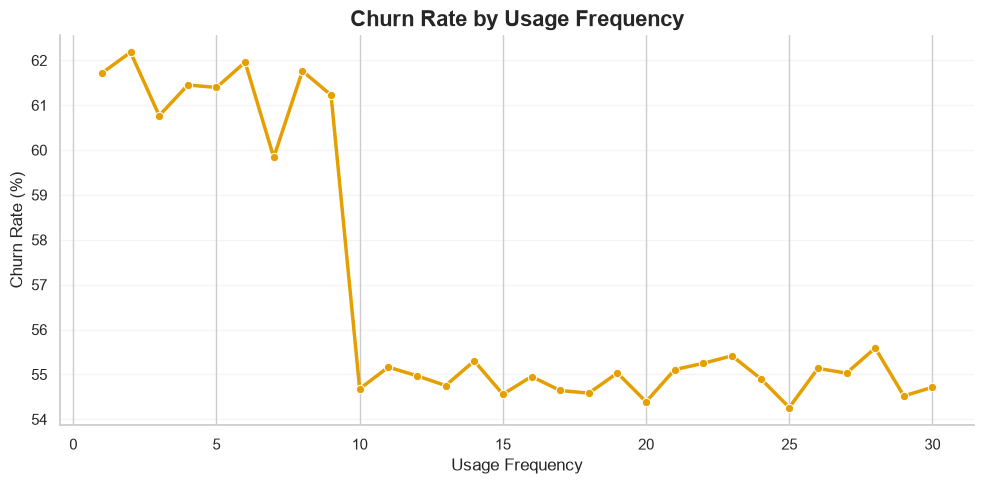

In [25]:
plt.figure(figsize=(10, 5))

sns.lineplot(
    data=usage_churn,
    x="Usage Frequency",
    y="Churn Rate (%)",
    marker="o",
    linewidth=2.5,
    color="#E69F00"
)

plt.title(
    "Churn Rate by Usage Frequency",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Usage Frequency")
plt.ylabel("Churn Rate (%)")

plt.grid(axis="y", alpha=0.2)

sns.despine()
plt.tight_layout()
plt.show()

#### 12. Total Spend and Customer Churn

Customer spending is compared between churned and non-churned customers to determine whether lower customer spending is associated with churn.

In [26]:
# Compare total spend by churn status

spend_churn = (
    df_clean.groupby("Churn")["Total Spend"]
    .agg(["count", "mean", "median"])
    .reset_index()
)

spend_churn["Churn Status"] = spend_churn["Churn"].map({
    0: "No Churn",
    1: "Churn"
})

spend_churn

,Churn,count,mean,median,Churn Status
0,0.00,190833,749.95,749.98,No Churn
1,1.00,249999,541.29,534.00,Churn


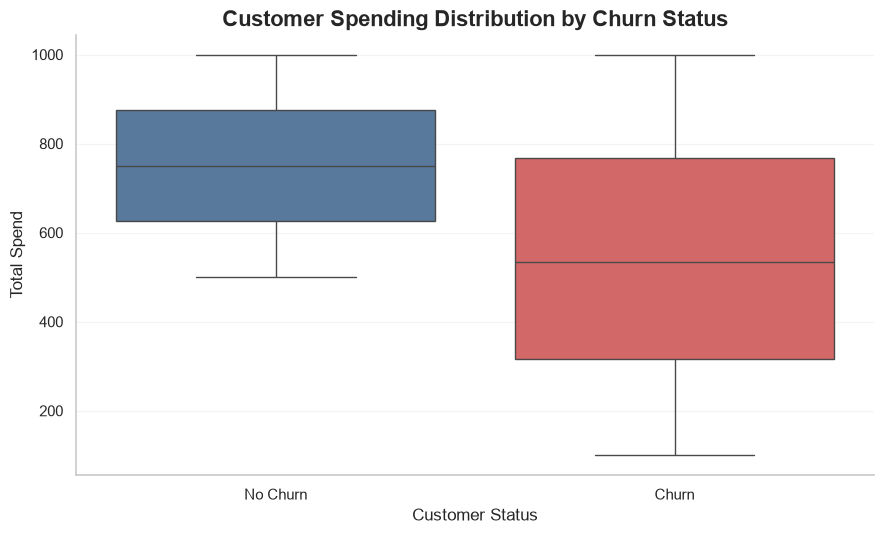

In [27]:
plt.figure(figsize=(9, 5.5))

sns.boxplot(
    data=df_clean,
    x="Churn",
    y="Total Spend",
    hue="Churn",
    legend=False,
    palette=["#4C78A8", "#E45756"]
)

plt.title(
    "Customer Spending Distribution by Churn Status",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Customer Status")
plt.ylabel("Total Spend")

plt.xticks(
    [0, 1],
    ["No Churn", "Churn"]
)

plt.grid(axis="y", alpha=0.2)

sns.despine()
plt.tight_layout()
plt.show()

#### 13. Last Interaction and Customer Churn

The number of days since the customer's last interaction is compared between churned and non-churned customers to identify whether lower engagement over time is associated with churn.

In [28]:
# Compare last interaction by churn status

interaction_churn = (
    df_clean.groupby("Churn")["Last Interaction"]
    .agg(["count", "mean", "median"])
    .reset_index()
)

interaction_churn["Churn Status"] = interaction_churn["Churn"].map({
    0: "No Churn",
    1: "Churn"
})

interaction_churn

,Churn,count,mean,median,Churn Status
0,0.00,190833,13.01,12.00,No Churn
1,1.00,249999,15.60,16.00,Churn


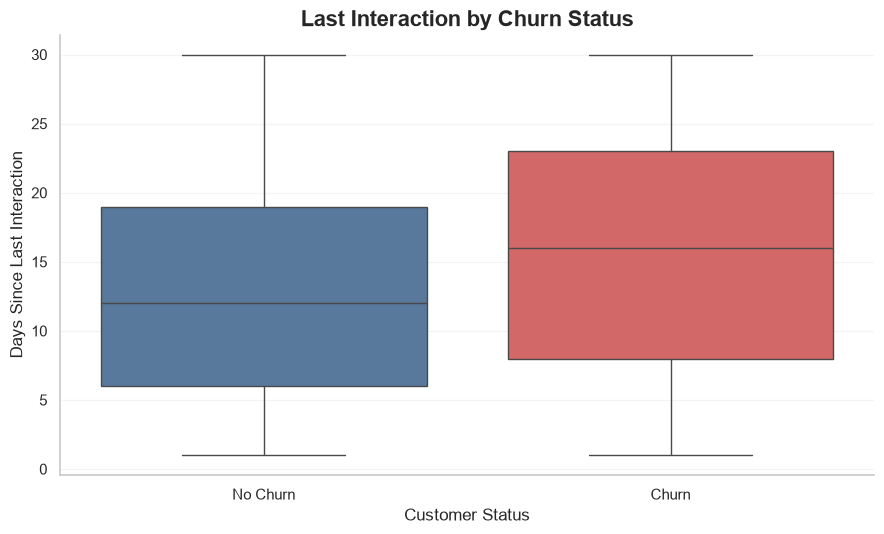

In [29]:
plt.figure(figsize=(9, 5.5))

sns.boxplot(
    data=df_clean,
    x="Churn",
    y="Last Interaction",
    hue="Churn",
    legend=False,
    palette=["#4C78A8", "#E45756"]
)

plt.title(
    "Last Interaction by Churn Status",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Customer Status")
plt.ylabel("Days Since Last Interaction")

plt.xticks(
    [0, 1],
    ["No Churn", "Churn"]
)

plt.grid(axis="y", alpha=0.2)

sns.despine()
plt.tight_layout()
plt.show()

#### 14. Churn Rate by Subscription Type and Contract Length

The interaction between subscription type and contract length is analyzed to identify customer segments with particularly high churn rates.

In [30]:
# Calculate churn rate by subscription and contract length

subscription_contract = (
    df_clean
    .groupby(["Subscription Type", "Contract Length"])["Churn"]
    .agg(["count", "mean"])
    .reset_index()
)

subscription_contract["Churn Rate (%)"] = (
    subscription_contract["mean"] * 100
)

subscription_contract

,Subscription Type,Contract Length,count,mean,Churn Rate (%)
0,Basic,Annual,57355,0.47,47.45
1,Basic,Monthly,29050,1.00,100.00
2,Basic,Quarterly,56621,0.48,47.59
3,Premium,Annual,59828,0.45,45.39
4,Premium,Monthly,29069,1.00,100.00
5,Premium,Quarterly,59781,0.45,45.08
6,Standard,Annual,60015,0.45,45.45
7,Standard,Monthly,28985,1.00,100.00
8,Standard,Quarterly,60128,0.45,45.50


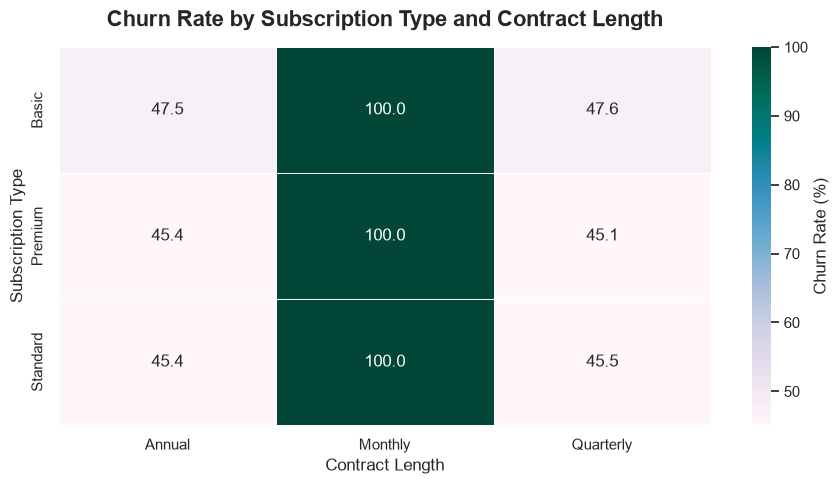

In [31]:
churn_heatmap = (
    subscription_contract
    .pivot(
        index="Subscription Type",
        columns="Contract Length",
        values="Churn Rate (%)"
    )
)

plt.figure(figsize=(9, 5))

sns.heatmap(
    churn_heatmap,
    annot=True,
    fmt=".1f",
    linewidths=0.5,
    cmap="PuBuGn",
    cbar_kws={"label": "Churn Rate (%)"}
)

plt.title(
    "Churn Rate by Subscription Type and Contract Length",
    fontsize=16,
    fontweight="bold",
    pad=15
)

plt.xlabel("Contract Length")
plt.ylabel("Subscription Type")

plt.tight_layout()
plt.show()

#### 15. Correlation Analysis

Correlation analysis is performed on numerical variables to identify which features have stronger linear relationships with customer churn.

In [32]:
# Calculate correlations with churn

numeric_features = [
    "Age",
    "Tenure",
    "Usage Frequency",
    "Support Calls",
    "Payment Delay",
    "Total Spend",
    "Last Interaction",
    "Churn"
]

correlation_matrix = df_clean[numeric_features].corr()

correlation_matrix["Churn"].sort_values(
    ascending=False
)

Churn               1.00
Support Calls       0.57
Payment Delay       0.31
Age                 0.22
Last Interaction    0.15
Usage Frequency    -0.05
Tenure             -0.05
Total Spend        -0.43
Name: Churn, dtype: float64

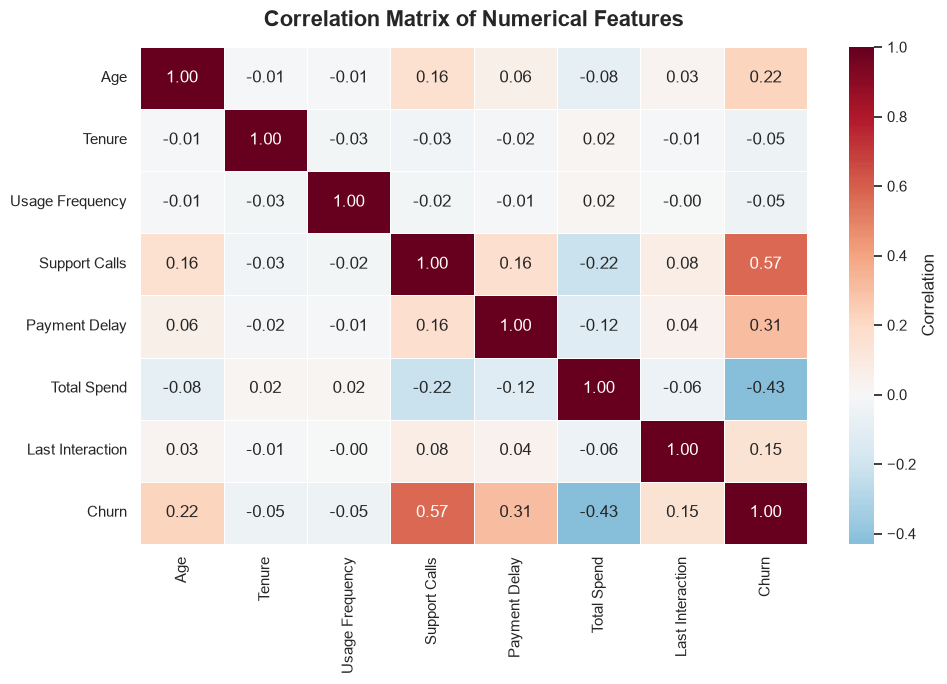

In [33]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    center=0,
    cmap="RdBu_r",
    cbar_kws={"label": "Correlation"}
)

plt.title(
    "Correlation Matrix of Numerical Features",
    fontsize=16,
    fontweight="bold",
    pad=15
)

plt.tight_layout()
plt.show()

#### 16. Machine Learning Preparation

The target variable is separated from the predictor variables. CustomerID is excluded because it is an identifier and does not provide meaningful predictive information.

In [34]:
# Separate features and target

X = df_clean.drop(
    columns=["CustomerID", "Churn"]
)

y = df_clean["Churn"]

print("Feature shape:", X.shape)
print("Target shape :", y.shape)

print("\nFeatures:")
print(X.columns.tolist())

print("\nTarget distribution:")
print(y.value_counts())

Feature shape: (440832, 10)
Target shape : (440832,)

Features:
['Age', 'Gender', 'Tenure', 'Usage Frequency', 'Support Calls', 'Payment Delay', 'Subscription Type', 'Contract Length', 'Total Spend', 'Last Interaction']

Target distribution:
Churn
1.00    249999
0.00    190833
Name: count, dtype: int64


#### 17. Train-Test Split

The dataset is divided into training and testing sets using an 80:20 ratio. Stratification is applied to maintain a similar churn distribution in both datasets.

In [35]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set :", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True))

print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True))

Training set: (352665, 10)
Testing set : (88167, 10)

Training target distribution:
Churn
1.00   0.57
0.00   0.43
Name: proportion, dtype: float64

Testing target distribution:
Churn
1.00   0.57
0.00   0.43
Name: proportion, dtype: float64


#### 18. Data Preprocessing

Numerical variables are standardized using StandardScaler, while categorical variables are transformed using OneHotEncoder. A ColumnTransformer is used to apply the appropriate preprocessing method to each feature type.

In [36]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

numerical_features = [
    "Age",
    "Tenure",
    "Usage Frequency",
    "Support Calls",
    "Payment Delay",
    "Total Spend",
    "Last Interaction"
]

categorical_features = [
    "Gender",
    "Subscription Type",
    "Contract Length"
]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_features
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ]
)

print("Numerical features:", len(numerical_features))
print("Categorical features:", len(categorical_features))
print("Preprocessing pipeline created successfully!")

Numerical features: 7
Categorical features: 3
Preprocessing pipeline created successfully!


#### 19. Logistic Regression Baseline

Logistic Regression is used as a baseline classification model. It provides an interpretable benchmark before comparing its performance with a more flexible ensemble model.

In [37]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

logistic_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            LogisticRegression(
                max_iter=1000,
                random_state=42
            )
        )
    ]
)

print("Logistic Regression pipeline created successfully!")

Logistic Regression pipeline created successfully!


In [38]:
# Train Logistic Regression

logistic_pipeline.fit(
    X_train,
    y_train
)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


#### 20. Logistic Regression Evaluation

The Logistic Regression model is evaluated using accuracy, precision, recall, F1-score, and ROC-AUC. These metrics provide a broader view of classification performance, particularly for identifying churned customers.

In [39]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

y_pred = logistic_pipeline.predict(X_test)

y_pred_proba = (
    logistic_pipeline
    .predict_proba(X_test)[:, 1]
)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print("=== Logistic Regression Evaluation ===")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-Score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")

print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred))

=== Logistic Regression Evaluation ===
Accuracy : 0.8934
Precision: 0.9234
Recall   : 0.8855
F1-Score : 0.9040
ROC-AUC  : 0.9590

=== Classification Report ===
              precision    recall  f1-score   support

         0.0       0.86      0.90      0.88     38167
         1.0       0.92      0.89      0.90     50000

    accuracy                           0.89     88167
   macro avg       0.89      0.89      0.89     88167
weighted avg       0.89      0.89      0.89     88167



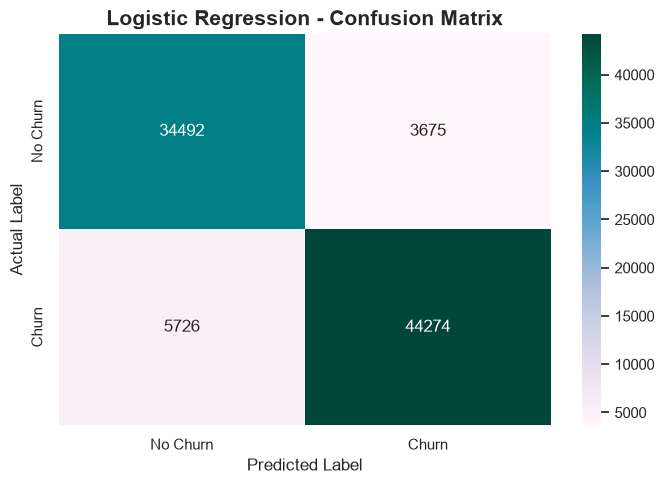

In [40]:
cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="PuBuGn",
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"]
)

plt.title(
    "Logistic Regression - Confusion Matrix",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.tight_layout()
plt.show()

#### 21. Random Forest Classification

Random Forest is introduced as a second model because it can capture nonlinear relationships and interactions between customer characteristics that may not be fully captured by Logistic Regression.

In [41]:
from sklearn.ensemble import RandomForestClassifier

random_forest_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestClassifier(
                n_estimators=100,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

print("Random Forest pipeline created successfully!")

Random Forest pipeline created successfully!


In [42]:
# Train Random Forest

random_forest_pipeline.fit(
    X_train,
    y_train
)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


#### 22. Random Forest Evaluation

The Random Forest model is evaluated using the same metrics as Logistic Regression so that the two models can be compared consistently.

In [43]:
y_pred_rf = random_forest_pipeline.predict(X_test)

y_pred_proba_rf = (
    random_forest_pipeline
    .predict_proba(X_test)[:, 1]
)

accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
roc_auc_rf = roc_auc_score(
    y_test,
    y_pred_proba_rf
)

print("=== Random Forest Evaluation ===")
print(f"Accuracy : {accuracy_rf:.4f}")
print(f"Precision: {precision_rf:.4f}")
print(f"Recall   : {recall_rf:.4f}")
print(f"F1-Score : {f1_rf:.4f}")
print(f"ROC-AUC  : {roc_auc_rf:.4f}")

print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred_rf))

=== Random Forest Evaluation ===
Accuracy : 0.9993
Precision: 0.9999
Recall   : 0.9988
F1-Score : 0.9993
ROC-AUC  : 1.0000

=== Classification Report ===
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00     38167
         1.0       1.00      1.00      1.00     50000

    accuracy                           1.00     88167
   macro avg       1.00      1.00      1.00     88167
weighted avg       1.00      1.00      1.00     88167



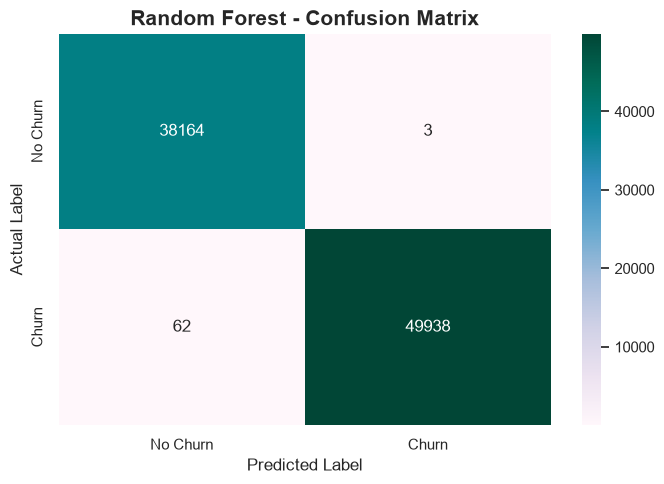

In [44]:
cm_rf = confusion_matrix(
    y_test,
    y_pred_rf
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="PuBuGn",
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"]
)

plt.title(
    "Random Forest - Confusion Matrix",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.tight_layout()
plt.show()

#### 23. Model Performance Comparison

The performance of Logistic Regression and Random Forest is compared across accuracy, precision, recall, F1-score, and ROC-AUC to identify the more suitable model for customer churn prediction.

In [45]:
model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy,
        accuracy_rf
    ],
    "Precision": [
        precision,
        precision_rf
    ],
    "Recall": [
        recall,
        recall_rf
    ],
    "F1-Score": [
        f1,
        f1_rf
    ],
    "ROC-AUC": [
        roc_auc,
        roc_auc_rf
    ]
})

model_comparison

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.89,0.92,0.89,0.90,0.96
1,Random Forest,1.00,1.00,1.00,1.00,1.00


#### 24. ROC Curve Comparison

ROC curves are used to compare the ability of Logistic Regression and Random Forest to distinguish between churned and non-churned customers across different classification thresholds.

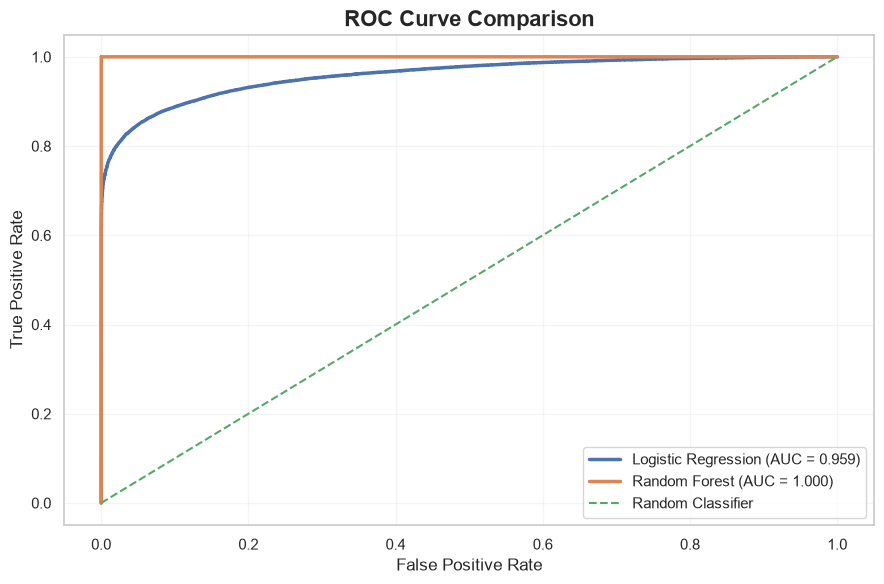

In [46]:
from sklearn.metrics import roc_curve

fpr_lr, tpr_lr, _ = roc_curve(
    y_test,
    y_pred_proba
)

fpr_rf, tpr_rf, _ = roc_curve(
    y_test,
    y_pred_proba_rf
)

plt.figure(figsize=(9, 6))

plt.plot(
    fpr_lr,
    tpr_lr,
    linewidth=2.5,
    label=f"Logistic Regression (AUC = {roc_auc:.3f})"
)

plt.plot(
    fpr_rf,
    tpr_rf,
    linewidth=2.5,
    label=f"Random Forest (AUC = {roc_auc_rf:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1.5,
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title(
    "ROC Curve Comparison",
    fontsize=16,
    fontweight="bold"
)

plt.legend(loc="lower right")
plt.grid(alpha=0.2)

plt.tight_layout()
plt.show()

#### 25. Feature Importance

Feature importance from the Random Forest model is analyzed to identify which customer characteristics contribute most strongly to the model's churn predictions.

In [47]:
feature_names = (
    random_forest_pipeline
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

importances = (
    random_forest_pipeline
    .named_steps["model"]
    .feature_importances_
)

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(15)

,Feature,Importance
3,num__Support Calls,0.29
5,num__Total Spend,0.20
0,num__Age,0.13
4,num__Payment Delay,0.13
13,cat__Contract Length_Monthly,0.10
6,num__Last Interaction,0.05
12,cat__Contract Length_Annual,0.02
14,cat__Contract Length_Quarterly,0.02
8,cat__Gender_Male,0.02
7,cat__Gender_Female,0.02


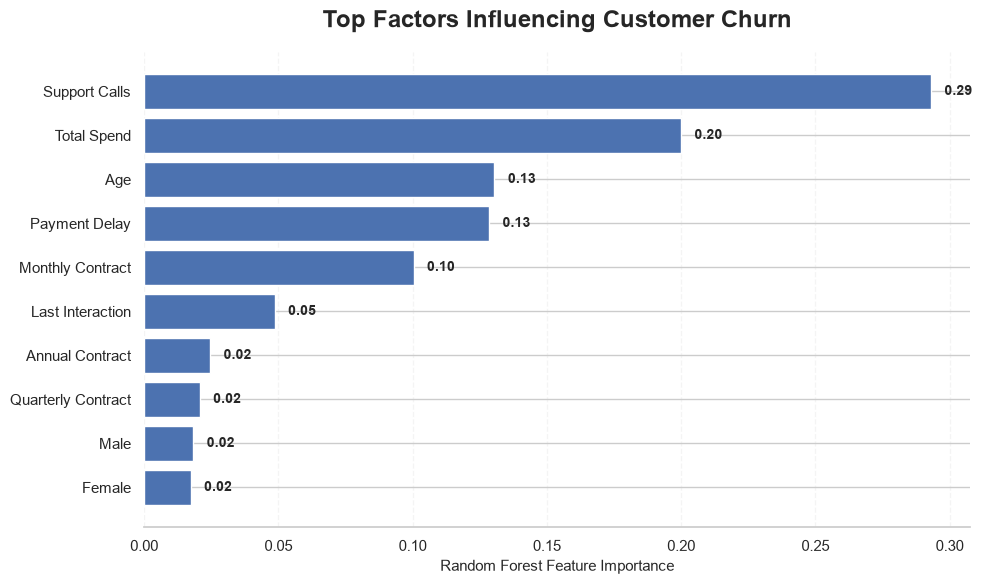

In [61]:
# Visualize Top 10 Random Forest Feature Importance

top_features = (
    feature_importance
    .head(10)
    .sort_values("Importance", ascending=True)
    .copy()
)

# Rename features for cleaner visualization
feature_labels = {
    "num__Support Calls": "Support Calls",
    "num__Total Spend": "Total Spend",
    "num__Age": "Age",
    "num__Payment Delay": "Payment Delay",
    "cat__Contract Length_Monthly": "Monthly Contract",
    "num__Last Interaction": "Last Interaction",
    "cat__Contract Length_Annual": "Annual Contract",
    "cat__Contract Length_Quarterly": "Quarterly Contract",
    "cat__Gender_Male": "Male",
    "cat__Gender_Female": "Female"
}

top_features["Feature"] = (
    top_features["Feature"]
    .map(feature_labels)
    .fillna(top_features["Feature"])
)

# Create visualization
fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(
    top_features["Feature"],
    top_features["Importance"]
)

# Add values to bars
for bar, value in zip(bars, top_features["Importance"]):
    ax.text(
        value + 0.005,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.2f}",
        va="center",
        fontsize=10,
        fontweight="bold"
    )

# Styling
ax.set_title(
    "Top Factors Influencing Customer Churn",
    fontsize=17,
    fontweight="bold",
    pad=18
)

ax.set_xlabel(
    "Random Forest Feature Importance",
    fontsize=11
)

ax.set_ylabel("")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

ax.grid(
    axis="x",
    linestyle="--",
    alpha=0.2
)

ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

#### 26. Model Validation with Cross-Validation

Five-fold stratified cross-validation is used to evaluate the consistency of the Random Forest model across different subsets of the training data.

In [49]:
from sklearn.model_selection import (
    StratifiedKFold,
    cross_val_score
)

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_scores = cross_val_score(
    random_forest_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1
)

print("Random Forest 5-Fold Cross-Validation ROC-AUC:")
print(cv_scores)

print(f"\nMean ROC-AUC: {cv_scores.mean():.4f}")
print(f"Std ROC-AUC : {cv_scores.std():.4f}")

Random Forest 5-Fold Cross-Validation ROC-AUC:
[0.99999917 0.99999973 0.99999947 0.99999892 0.99999971]

Mean ROC-AUC: 1.0000
Std ROC-AUC : 0.0000


#### 27. Customer Churn Probability

The Random Forest model is used to estimate the probability of churn for each customer in the testing dataset. These probabilities are then used to classify customers into different risk levels.

In [51]:
churn_probability = (
    random_forest_pipeline
    .predict_proba(X_test)[:, 1]
)

churn_predictions = X_test.copy()

churn_predictions["Actual Churn"] = y_test.values
churn_predictions["Churn Probability"] = churn_probability
churn_predictions["Predicted Churn"] = y_pred_rf

churn_predictions.head(10)

,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Actual Churn,Churn Probability,Predicted Churn
30086,62.00,Female,49.00,20.00,0.00,19.00,Basic,Monthly,175.00,22.00,1.00,1.00,1.00
368225,29.00,Male,32.00,27.00,2.00,2.00,Standard,Quarterly,733.00,25.00,0.00,0.00,0.00
146939,40.00,Female,39.00,16.00,8.00,0.00,Basic,Quarterly,542.00,3.00,1.00,1.00,1.00
368276,23.00,Female,13.00,28.00,0.00,11.00,Basic,Quarterly,951.67,1.00,0.00,0.01,0.00
153765,18.00,Male,10.00,15.00,3.00,15.00,Standard,Quarterly,970.00,17.00,1.00,0.67,1.00
143013,21.00,Male,55.00,28.00,10.00,8.00,Premium,Monthly,320.00,22.00,1.00,1.00,1.00
409988,32.00,Male,48.00,24.00,3.00,7.00,Basic,Quarterly,630.44,19.00,0.00,0.00,0.00
299645,33.00,Male,34.00,10.00,1.00,9.00,Basic,Quarterly,936.98,10.00,0.00,0.00,0.00
11149,50.00,Male,1.00,25.00,10.00,27.00,Basic,Annual,739.00,3.00,1.00,1.00,1.00
15124,29.00,Female,33.00,29.00,2.00,3.00,Premium,Monthly,390.00,5.00,1.00,1.00,1.00


#### 28. Customer Risk Segmentation

Customers are categorized into Low, Medium, and High churn risk based on their predicted churn probability. This segmentation helps translate model predictions into actionable customer retention strategies.

In [52]:
def assign_risk_level(probability):
    if probability < 0.30:
        return "Low"
    elif probability < 0.70:
        return "Medium"
    else:
        return "High"


churn_predictions["Risk Level"] = (
    churn_predictions["Churn Probability"]
    .apply(assign_risk_level)
)

churn_predictions[
    [
        "Churn Probability",
        "Predicted Churn",
        "Risk Level"
    ]
].head(10)

,Churn Probability,Predicted Churn,Risk Level
30086,1.00,1.00,High
368225,0.00,0.00,Low
146939,1.00,1.00,High
368276,0.01,0.00,Low
153765,0.67,1.00,Medium
143013,1.00,1.00,High
409988,0.00,0.00,Low
299645,0.00,0.00,Low
11149,1.00,1.00,High
15124,1.00,1.00,High


#### 29. Customer Churn Risk Distribution

The distribution of customers across Low, Medium, and High churn risk categories is examined to understand the scale of customers that may require retention attention.

In [53]:
risk_distribution = (
    churn_predictions["Risk Level"]
    .value_counts()
    .reindex(["Low", "Medium", "High"])
    .fillna(0)
)

risk_distribution

Risk Level
Low       38160
Medium      315
High      49692
Name: count, dtype: int64

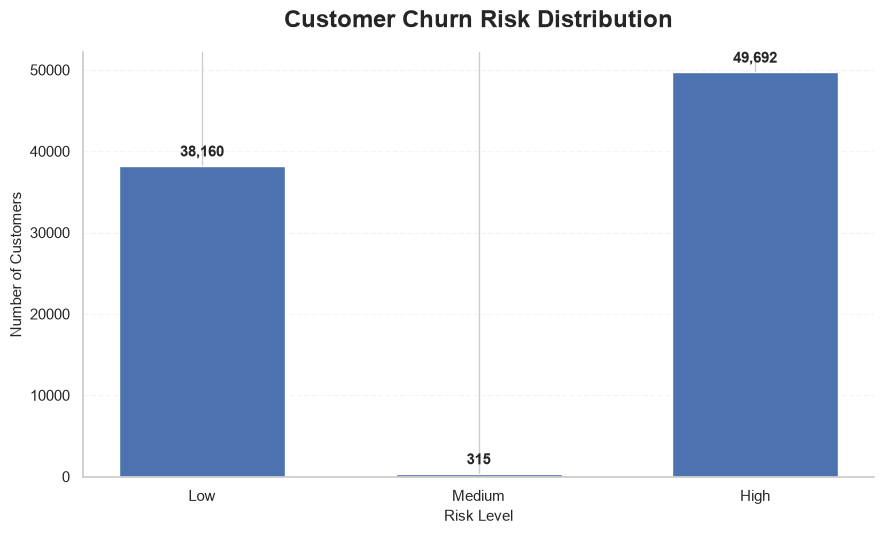

In [62]:
# Visualize Customer Churn Risk Distribution

risk_counts = risk_distribution.reindex(
    ["Low", "Medium", "High"]
)

# Create figure
fig, ax = plt.subplots(figsize=(9, 5.5))

bars = ax.bar(
    risk_counts.index,
    risk_counts.values,
    width=0.6
)

# Add value labels
for bar, value in zip(bars, risk_counts.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 800,
        f"{value:,}",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold"
    )

# Styling
ax.set_title(
    "Customer Churn Risk Distribution",
    fontsize=17,
    fontweight="bold",
    pad=18
)

ax.set_xlabel(
    "Risk Level",
    fontsize=11
)

ax.set_ylabel(
    "Number of Customers",
    fontsize=11
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.2
)

ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

#### 30. Business Recommendations

The model results are translated into practical customer retention strategies. Customers with higher predicted churn probabilities should receive more proactive and personalized interventions.

In [55]:
retention_strategy = pd.DataFrame({
    "Risk Level": [
        "High",
        "Medium",
        "Low"
    ],
    "Customer Condition": [
        "High churn probability",
        "Moderate churn probability",
        "Low churn probability"
    ],
    "Recommended Action": [
        "Priority retention: proactive support, personalized offers, and payment assistance",
        "Engagement campaign: reminders, targeted promotions, and usage incentives",
        "Maintain relationship: loyalty programs, regular engagement, and satisfaction monitoring"
    ]
})

retention_strategy

,Risk Level,Customer Condition,Recommended Action
0,High,High churn probability,"Priority retention: proactive support, persona..."
1,Medium,Moderate churn probability,"Engagement campaign: reminders, targeted promo..."
2,Low,Low churn probability,"Maintain relationship: loyalty programs, regul..."


#### 31. Final Business Insights

The analysis identifies several important patterns associated with customer churn. Higher support call frequency, longer periods since the last interaction, and lower total spending are associated with greater churn risk. Contract length is also a particularly strong segmentation factor, with monthly customers showing substantially higher churn in this dataset.

These findings can be used to prioritize proactive customer support, engagement campaigns, personalized retention offers, and payment assistance.

In [56]:
final_insights = pd.DataFrame({
    "Insight": [
        "Support Calls",
        "Payment Delay",
        "Total Spend",
        "Usage Frequency",
        "Last Interaction",
        "Contract Length"
    ],
    "Observed Pattern": [
        "Churn increases substantially as support calls increase",
        "Churn remains relatively stable up to 20 days, then increases sharply",
        "Churned customers have lower average spending",
        "Lower usage is associated with higher churn",
        "Churned customers have longer periods since last interaction",
        "Monthly contracts show substantially higher churn"
    ],
    "Business Recommendation": [
        "Prioritize proactive customer support",
        "Provide payment reminders and assistance",
        "Offer personalized retention incentives",
        "Increase engagement and product usage",
        "Re-engage inactive customers",
        "Encourage longer-term contract plans"
    ]
})

final_insights

,Insight,Observed Pattern,Business Recommendation
0,Support Calls,Churn increases substantially as support calls...,Prioritize proactive customer support
1,Payment Delay,"Churn remains relatively stable up to 20 days,...",Provide payment reminders and assistance
2,Total Spend,Churned customers have lower average spending,Offer personalized retention incentives
3,Usage Frequency,Lower usage is associated with higher churn,Increase engagement and product usage
4,Last Interaction,Churned customers have longer periods since la...,Re-engage inactive customers
5,Contract Length,Monthly contracts show substantially higher churn,Encourage longer-term contract plans


#### 32. Save the Final Model

The trained Random Forest pipeline, including preprocessing and classification steps, is saved so that it can be reused for future customer churn predictions.

In [63]:
import joblib

joblib.dump(
    random_forest_pipeline,
    "../models/customer_churn_random_forest.pkl"
)

print("Final Random Forest model saved successfully!")

Final Random Forest model saved successfully!


#### 33. Export Customer Predictions

The customer-level churn predictions, probabilities, and risk classifications are exported as a CSV file for further analysis or potential business use.

In [64]:
churn_predictions.to_csv(
    "../outputs/customer_churn_predictions.csv",
    index=True
)

print(
    "Customer churn predictions exported successfully!"
)

Customer churn predictions exported successfully!


#### 34. Final Model Performance

The final model performance is summarized below to provide a direct comparison between the baseline Logistic Regression model and the Random Forest model.

In [59]:
final_model_summary = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC"
    ],
    "Logistic Regression": [
        accuracy,
        precision,
        recall,
        f1,
        roc_auc
    ],
    "Random Forest": [
        accuracy_rf,
        precision_rf,
        recall_rf,
        f1_rf,
        roc_auc_rf
    ]
})

final_model_summary

,Metric,Logistic Regression,Random Forest
0,Accuracy,0.89,1.00
1,Precision,0.92,1.00
2,Recall,0.89,1.00
3,F1-Score,0.90,1.00
4,ROC-AUC,0.96,1.00


#### Conclusion

This project developed a customer churn prediction system using exploratory data analysis and machine learning.

The analysis showed several important churn patterns. Customers with frequent support interactions, lower total spending, lower engagement, and longer periods since their last interaction tend to exhibit higher churn risk. Contract length also emerged as an important segmentation factor, particularly because monthly-contract customers show substantially higher churn in this dataset.

Two classification models were evaluated: Logistic Regression and Random Forest. Their performance was compared using accuracy, precision, recall, F1-score, and ROC-AUC. Random Forest was additionally evaluated using five-fold stratified cross-validation and feature importance analysis.

The final model provides customer-level churn probabilities and risk categories that can support targeted retention strategies. High-risk customers can be prioritized for proactive support and personalized retention offers, while medium- and low-risk customers can be managed through engagement and loyalty initiatives.

Overall, this project demonstrates how customer data and machine learning can be transformed into actionable insights for customer retention and churn management.